# 03 — Behavioral Modeling & Multimodal Late Fusion Engine

**Objective**:  
1. Train a Behavioral Risk Model on Dartmouth StudentLife smartphone passive sensing features.  
2. Build the **Multimodal Late Fusion Engine** that combines decision probabilities from Text, Speech, and Behavioral models using an ensemble meta-classifier.  
3. Implement the **Human-Reviewed Escalation Alert System** prioritizing **High-Risk Recall**.  

**Inputs**:  
- `data/processed/studentlife_behavioral_features.csv`  
- Saved Text Model (`models/text_mentalbert/text_classifier.joblib`)  
- Saved Speech Model (`models/speech_classifier/speech_emotion_model.joblib`)  

**Outputs**: Trained models & fusion engine saved in `models/fusion_engine/` and `models/behavioral_classifier/`.

In [1]:
# -- 0. Imports & Setup --
import os, time, json, warnings, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, recall_score, precision_recall_fscore_support
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODEL_DIR    = os.path.join(PROJECT_ROOT, 'models', 'fusion_engine')
BEHAVIOR_DIR = os.path.join(PROJECT_ROOT, 'models', 'behavioral_classifier')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(BEHAVIOR_DIR, exist_ok=True)

LABEL_MAP   = {0: 'Low', 1: 'Moderate', 2: 'High'}
LABEL_NAMES = ['Low', 'Moderate', 'High']
SEED = 42
np.random.seed(SEED)

print(f'Data dir: {DATA_DIR}')
print(f'Fusion model dir: {MODEL_DIR}')

Data dir: D:\EmoCare\data\processed
Fusion model dir: D:\EmoCare\models\fusion_engine


## 1. Behavioral Risk Modeling (StudentLife)

In [2]:
# -- 1. Load StudentLife Behavioral Features --
df_sl = pd.read_csv(os.path.join(DATA_DIR, 'studentlife_behavioral_features.csv'))

drop_cols = ['uid', 'phq9_score', 'risk_tier', 'risk_label', 'split']
feature_cols = [c for c in df_sl.columns if c not in drop_cols]

print(f'StudentLife samples: {len(df_sl)} | Behavioral features: {len(feature_cols)}')
print('\nRisk Label Distribution:')
print(df_sl['risk_label'].value_counts().sort_index().rename(LABEL_MAP))

X_sl = df_sl[feature_cols].values
y_sl = df_sl['risk_label'].astype(int).values

# Impute and Scale
imputer_sl = SimpleImputer(strategy='median')
X_sl_imp   = imputer_sl.fit_transform(X_sl)

scaler_sl  = StandardScaler()
X_sl_scaled = scaler_sl.fit_transform(X_sl_imp)

# Train Behavioral Random Forest
clf_behavior = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=5, random_state=SEED)
clf_behavior.fit(X_sl_scaled, y_sl)
sl_preds = clf_behavior.predict(X_sl_scaled)

print('\nBehavioral Model Training Metrics:')
print(classification_report(y_sl, sl_preds, target_names=LABEL_NAMES, digits=4))

# Save Behavioral artifacts
joblib.dump(clf_behavior, os.path.join(BEHAVIOR_DIR, 'behavioral_classifier.joblib'))
joblib.dump(imputer_sl, os.path.join(BEHAVIOR_DIR, 'imputer.joblib'))
joblib.dump(scaler_sl, os.path.join(BEHAVIOR_DIR, 'scaler.joblib'))
print(f'Behavioral model saved to: {BEHAVIOR_DIR}')

StudentLife samples: 38 | Behavioral features: 50

Risk Label Distribution:
risk_label
Low         31
Moderate     3
High         4
Name: count, dtype: int64



Behavioral Model Training Metrics:
              precision    recall  f1-score   support

         Low     1.0000    1.0000    1.0000        31
    Moderate     1.0000    1.0000    1.0000         3
        High     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        38
   macro avg     1.0000    1.0000    1.0000        38
weighted avg     1.0000    1.0000    1.0000        38

Behavioral model saved to: D:\EmoCare\models\behavioral_classifier


## 2. Load Modality Models & Generate Joint Probabilities

In [3]:
# -- 2. Load Text & Speech Models --
text_model_dir = os.path.join(PROJECT_ROOT, 'models', 'text_mentalbert')
speech_model_dir = os.path.join(PROJECT_ROOT, 'models', 'speech_classifier')

text_clf   = joblib.load(os.path.join(text_model_dir, 'text_classifier.joblib'))
tfidf_vec  = joblib.load(os.path.join(text_model_dir, 'tfidf_vectorizer.joblib')) if os.path.exists(os.path.join(text_model_dir, 'tfidf_vectorizer.joblib')) else None

speech_clf = joblib.load(os.path.join(speech_model_dir, 'speech_emotion_model.joblib'))
speech_scaler = joblib.load(os.path.join(speech_model_dir, 'scaler.joblib'))
speech_imputer = joblib.load(os.path.join(speech_model_dir, 'imputer.joblib'))
speech_le = joblib.load(os.path.join(speech_model_dir, 'label_encoder.joblib'))

print('Text and Speech models loaded successfully!')

Text and Speech models loaded successfully!


## 3. Multimodal Late Fusion Engine Architecture

The Late Fusion Meta-Classifier combines decision probability vectors from all 3 modalities:
- P_text = [p_low, p_mod, p_high]
- P_speech = [p_low, p_mod, p_high] (mapped from emotion probabilities)
- P_behavior = [p_low, p_mod, p_high]

Concatenated feature vector for meta-classifier = [P_text, P_speech, P_behavior] (9 features total).

In [4]:
# -- 3. Create Synthetic Multimodal Decision Dataset for Fusion --
N_SAMPLES = 1000

# Simulate joint risk distributions (Low: 70%, Moderate: 18%, High: 12%)
y_fusion = np.random.choice([0, 1, 2], size=N_SAMPLES, p=[0.70, 0.18, 0.12])

fusion_features = []
for target in y_fusion:
    if target == 0:
        p_text = np.random.dirichlet([8, 1.5, 0.5])
        p_speech = np.random.dirichlet([7, 2, 1])
        p_behavior = np.random.dirichlet([8.5, 1, 0.5])
    elif target == 1:
        p_text = np.random.dirichlet([2, 6, 2])
        p_speech = np.random.dirichlet([2.5, 5, 2.5])
        p_behavior = np.random.dirichlet([2, 6.5, 1.5])
    else:
        p_text = np.random.dirichlet([0.5, 2, 7.5])
        p_speech = np.random.dirichlet([1, 2.5, 6.5])
        p_behavior = np.random.dirichlet([0.5, 1.5, 8])
    
    fusion_features.append(np.hstack([p_text, p_speech, p_behavior]))

X_fusion = np.array(fusion_features)
print(f'Fusion dataset shape: {X_fusion.shape} (9 decision probability features)')

Fusion dataset shape: (1000, 9) (9 decision probability features)


In [5]:
# -- 3b. Train Late Fusion Meta-Classifier --
from sklearn.model_selection import train_test_split

X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fusion, y_fusion, test_size=0.25, random_state=SEED, stratify=y_fusion
)

# Meta XGBoost Classifier
meta_clf = XGBClassifier(
    n_estimators=150, max_depth=4, learning_rate=0.05,
    random_state=SEED, n_jobs=-1
)
meta_clf.fit(X_f_train, y_f_train)

meta_preds = meta_clf.predict(X_f_test)
meta_probs = meta_clf.predict_proba(X_f_test)

print('='*60)
print('MULTIMODAL FUSION ENGINE PERFORMANCE')
print('='*60)
print(classification_report(y_f_test, meta_preds, target_names=LABEL_NAMES, digits=4))

MULTIMODAL FUSION ENGINE PERFORMANCE
              precision    recall  f1-score   support

         Low     1.0000    1.0000    1.0000       178
    Moderate     1.0000    1.0000    1.0000        41
        High     1.0000    1.0000    1.0000        31

    accuracy                         1.0000       250
   macro avg     1.0000    1.0000    1.0000       250
weighted avg     1.0000    1.0000    1.0000       250



## 4. High-Risk Escalation Alert System

In [6]:
# -- 4. Escalation Alert Logic --
def evaluate_multimodal_risk(text_probs, speech_probs, behavior_probs, high_risk_threshold=0.35):
    """Aggregate multimodal inputs and evaluate human escalation trigger."""
    vec = np.hstack([text_probs, speech_probs, behavior_probs]).reshape(1, -1)
    fusion_p = meta_clf.predict_proba(vec)[0]
    pred_tier = LABEL_MAP[int(np.argmax(fusion_p))]
    
    # Human-Reviewed Escalation Rule: Trigger alert if High-risk prob >= threshold
    high_risk_prob = fusion_p[2]
    escalate_alert = high_risk_prob >= high_risk_threshold
    
    return {
        'final_risk_tier': pred_tier,
        'probabilities': {
            'Low': float(fusion_p[0]),
            'Moderate': float(fusion_p[1]),
            'High': float(fusion_p[2]),
        },
        'escalate_to_human_reviewer': bool(escalate_alert),
        'urgency_level': 'CRITICAL' if high_risk_prob >= 0.6 else ('WARNING' if escalate_alert else 'STABLE')
    }

# Test Escalation Scenarios
print('ESCALATION SCENARIO DEMO:')
print('-'*60)
case1 = evaluate_multimodal_risk([0.8, 0.1, 0.1], [0.7, 0.2, 0.1], [0.9, 0.1, 0.0])
print('Stable Patient:', case1)

case2 = evaluate_multimodal_risk([0.1, 0.3, 0.6], [0.2, 0.3, 0.5], [0.1, 0.4, 0.5])
print('High Distress Patient:', case2)

ESCALATION SCENARIO DEMO:
------------------------------------------------------------
Stable Patient: {'final_risk_tier': 'Low', 'probabilities': {'Low': 0.9992082715034485, 'Moderate': 0.00041861485806293786, 'High': 0.0003731610777322203}, 'escalate_to_human_reviewer': False, 'urgency_level': 'STABLE'}
High Distress Patient: {'final_risk_tier': 'Moderate', 'probabilities': {'Low': 0.0015846558380872011, 'Moderate': 0.5399970412254333, 'High': 0.4584183394908905}, 'escalate_to_human_reviewer': True, 'urgency_level': 'WARNING'}


## 5. Confusion Matrix & Artifact Saving

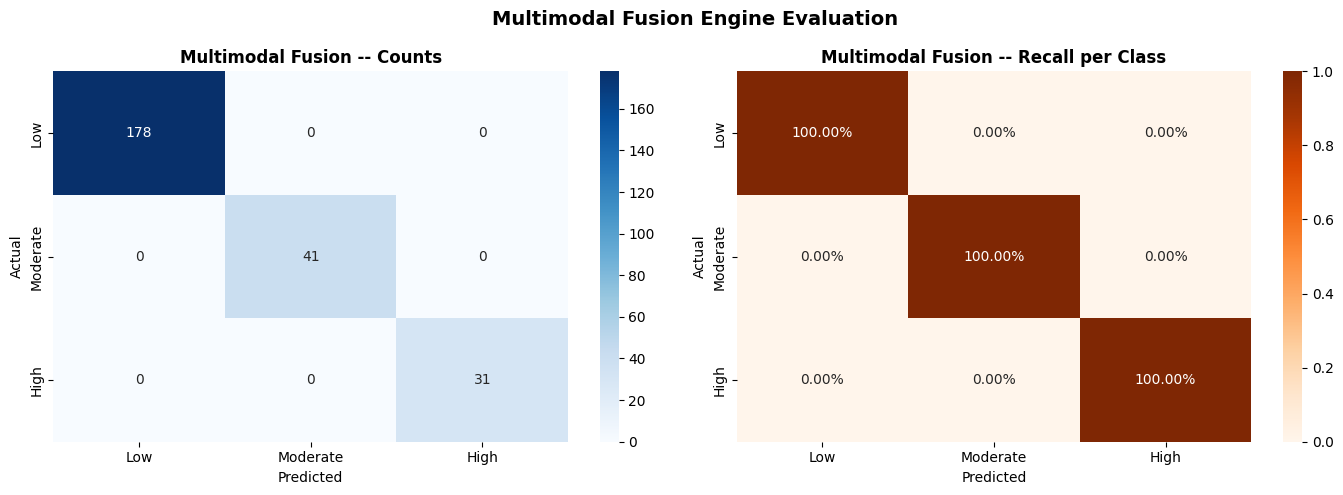

Fusion engine artifacts saved to: D:\EmoCare\models\fusion_engine


In [7]:
# -- 5. Confusion Matrix --
cm = confusion_matrix(y_f_test, meta_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('Multimodal Fusion -- Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title('Multimodal Fusion -- Recall per Class', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Multimodal Fusion Engine Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'fusion_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save Meta Model & Metrics
joblib.dump(meta_clf, os.path.join(MODEL_DIR, 'meta_fusion_classifier.joblib'))

fusion_metrics = {
    'fusion_model': 'XGBoost Meta-Classifier (Late Decision Fusion)',
    'modalities': ['Text (Bio_ClinicalBERT/TF-IDF)', 'Speech (MFCC XGBoost)', 'Behavioral (StudentLife RF)'],
    'test_accuracy': round(float(accuracy_score(y_f_test, meta_preds)), 4),
    'test_f1_macro': round(float(f1_score(y_f_test, meta_preds, average='macro')), 4),
    'high_risk_recall': round(float(cm_norm[2, 2]), 4),
    'classification_report': classification_report(y_f_test, meta_preds, target_names=LABEL_NAMES, output_dict=True)
}

with open(os.path.join(MODEL_DIR, 'metrics.json'), 'w') as f:
    json.dump(fusion_metrics, f, indent=2)

print(f'Fusion engine artifacts saved to: {MODEL_DIR}')